# **Libraries**

In [15]:
#system
from pathlib import Path

#data management
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
from scipy.stats import entropy
import missingno as msno

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

from IPython.display import display

#graph
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import plotly.express as px


# **Data**

Fuente Reclamos En Salud: https://mapas.supersalud.gov.co/arcgisportal/apps/sites/#/datos-abiertos 


# **Exploratory Data Analysis**

## **Structure**

In [3]:
dataf.shape

(9104342, 38)

In [4]:
dataf.columns

Index(['OBJECTID', 'PERIODO', 'MES', 'PQRCANAL', 'AFEC_PARENTESCO',
       'PET_COD_DEPTO', 'PET_COD_MPIO', 'ID_AFEC', 'AFEC_GENERO', 'AFEC_EDAD',
       'AFEC_EDADR', 'AFEC_EDUC', 'AFEC_REGAFILIACION', 'AFEC_GETNICO',
       'AFEC_POBESPECIAL', 'AFEC_COD_DEPTO', 'AFEC_COD_MPIO', 'ENT_NOMBRE',
       'ENT_TIPOVIG_SNS', 'ENT_COD_SNS', 'ENT_ALIAS_SNS', 'ENT_COD_DEPTO',
       'ENT_COD_MPIO', 'COD_MACROMOT', 'MACROMOTIVO', 'COD_MOTGEN',
       'MOTIVO_GENERAL', 'COD_MOTESP', 'MOTIVO_ESPECIFICO', 'COD_TIPO_MOTESP',
       'TIPO_DE_MOTIVO_ESPECIFICO', 'COD_SUBTIPO_MOTESP',
       'SUBTIPO_DE_MOTIVO_ESPECIFICO', 'PATOLOGIA_1', 'PATOLOGIA_TIPO',
       'CIE_10', 'ALTO_COSTO', 'CLASIFICACION_DE_RIESGO'],
      dtype='object')

In [6]:
dataf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9104342 entries, 0 to 9104341
Data columns (total 38 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   OBJECTID                      int64  
 1   PERIODO                       int64  
 2   MES                           int64  
 3   PQRCANAL                      object 
 4   AFEC_PARENTESCO               object 
 5   PET_COD_DEPTO                 float64
 6   PET_COD_MPIO                  float64
 7   ID_AFEC                       object 
 8   AFEC_GENERO                   object 
 9   AFEC_EDAD                     float64
 10  AFEC_EDADR                    object 
 11  AFEC_EDUC                     object 
 12  AFEC_REGAFILIACION            object 
 13  AFEC_GETNICO                  object 
 14  AFEC_POBESPECIAL              object 
 15  AFEC_COD_DEPTO                float64
 16  AFEC_COD_MPIO                 float64
 17  ENT_NOMBRE                    object 
 18  ENT_TIPOVIG_SNS       

In [47]:
dataf.dtypes

OBJECTID                          int64
PERIODO                           int64
MES                               int64
PQRCANAL                         object
AFEC_PARENTESCO                  object
PET_COD_DEPTO                   float64
PET_COD_MPIO                    float64
ID_AFEC                          object
AFEC_GENERO                      object
AFEC_EDAD                       float64
AFEC_EDADR                       object
AFEC_EDUC                        object
AFEC_REGAFILIACION               object
AFEC_GETNICO                     object
AFEC_POBESPECIAL                 object
AFEC_COD_DEPTO                  float64
AFEC_COD_MPIO                   float64
ENT_NOMBRE                       object
ENT_TIPOVIG_SNS                  object
ENT_COD_SNS                      object
ENT_ALIAS_SNS                    object
ENT_COD_DEPTO                     int64
ENT_COD_MPIO                      int64
COD_MACROMOT                      int64
MACROMOTIVO                      object


In [48]:
dataf.index

RangeIndex(start=0, stop=9104342, step=1)

## **Content And Quality**

In [7]:
null_values = dataf.isnull().mean() * 100
print(null_values.sort_values(ascending=False))

SUBTIPO_DE_MOTIVO_ESPECIFICO    79.364648
COD_SUBTIPO_MOTESP              79.364648
COD_TIPO_MOTESP                 63.081857
TIPO_DE_MOTIVO_ESPECIFICO       63.081857
CLASIFICACION_DE_RIESGO         61.728459
AFEC_EDAD                       61.728459
ENT_ALIAS_SNS                   11.418793
PQRCANAL                        11.418793
AFEC_COD_MPIO                    0.178157
AFEC_COD_DEPTO                   0.178157
PET_COD_DEPTO                    0.176663
PET_COD_MPIO                     0.176663
AFEC_GENERO                      0.132332
AFEC_REGAFILIACION               0.025570
AFEC_EDUC                        0.025460
AFEC_GETNICO                     0.025438
AFEC_EDADR                       0.025405
AFEC_POBESPECIAL                 0.009819
AFEC_PARENTESCO                  0.004009
MES                              0.000000
OBJECTID                         0.000000
PERIODO                          0.000000
ENT_COD_DEPTO                    0.000000
ENT_COD_SNS                      0

In [8]:
cardinality = dataf.nunique()
print(cardinality.sort_values(ascending=False))

ID_AFEC                         4561817
OBJECTID                        1247137
CIE_10                            16342
AFEC_COD_MPIO                      1124
PET_COD_MPIO                       1124
ENT_COD_MPIO                       1123
PATOLOGIA_TIPO                      702
COD_SUBTIPO_MOTESP                  353
MOTIVO_ESPECIFICO                   345
COD_MOTESP                          308
COD_TIPO_MOTESP                     236
ENT_ALIAS_SNS                       150
ENT_NOMBRE                          142
ENT_COD_SNS                         123
AFEC_EDAD                           120
SUBTIPO_DE_MOTIVO_ESPECIFICO        117
TIPO_DE_MOTIVO_ESPECIFICO           111
MOTIVO_GENERAL                       51
COD_MOTGEN                           34
PET_COD_DEPTO                        33
ENT_COD_DEPTO                        33
AFEC_COD_DEPTO                       33
ALTO_COSTO                           24
PATOLOGIA_1                          24
AFEC_PARENTESCO                      17


In [13]:
dataf["AFEC_EDAD"].describe()

count    2.537904e+06
mean     4.867606e+01
std      2.356894e+01
min      0.000000e+00
25%      3.100000e+01
50%      5.200000e+01
75%      6.700000e+01
max      1.250000e+02
Name: AFEC_EDAD, dtype: float64

# **Data Transformation**

In [11]:
dataf["DATE"] = pd.to_datetime(pd.DataFrame({
    'year': dataf["PERIODO"],
    'month': dataf["MES"],
    'day': 1
}))

In [12]:
print(dataf[['PERIODO', 'MES', 'DATE']].head())

   PERIODO  MES       DATE
0     2021   10 2021-10-01
1     2021    2 2021-02-01
2     2021    4 2021-04-01
3     2021   12 2021-12-01
4     2021    9 2021-09-01


In [13]:
dataf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9104342 entries, 0 to 9104341
Data columns (total 39 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   OBJECTID                      int64         
 1   PERIODO                       int64         
 2   MES                           int64         
 3   PQRCANAL                      object        
 4   AFEC_PARENTESCO               object        
 5   PET_COD_DEPTO                 float64       
 6   PET_COD_MPIO                  float64       
 7   ID_AFEC                       object        
 8   AFEC_GENERO                   object        
 9   AFEC_EDAD                     float64       
 10  AFEC_EDADR                    object        
 11  AFEC_EDUC                     object        
 12  AFEC_REGAFILIACION            object        
 13  AFEC_GETNICO                  object        
 14  AFEC_POBESPECIAL              object        
 15  AFEC_COD_DEPTO                fl

# **Advanced Exploratory Data Analysis**

In [23]:
age_data = supersalud.loc[supersalud['PERIODO'] > 2023, ['AFEC_EDAD']]

In [24]:
print(age_data.head())

         AFEC_EDAD
1684813       14.0
1684814       32.0
1684815       40.0
1684816       68.0
1684817       23.0


In [26]:
#skewness
age = 'AFEC_EDAD'
skew_value = age_data[age].skew()

In [27]:
if skew_value > 0.5:
    type = "Asimetria Positiva"
elif skew_value < -0.5:
    type = "Asimetria Negativa"
else:
    type = "Aproximadamente Simétrica"

print(f"Variable: {age}")
print(f"Coeficiente Skewness: {skew_value:.4f}")
print(f"Interpretación: {type}")

Variable: AFEC_EDAD
Coeficiente Skewness: -0.3135
Interpretación: Aproximadamente Simétrica


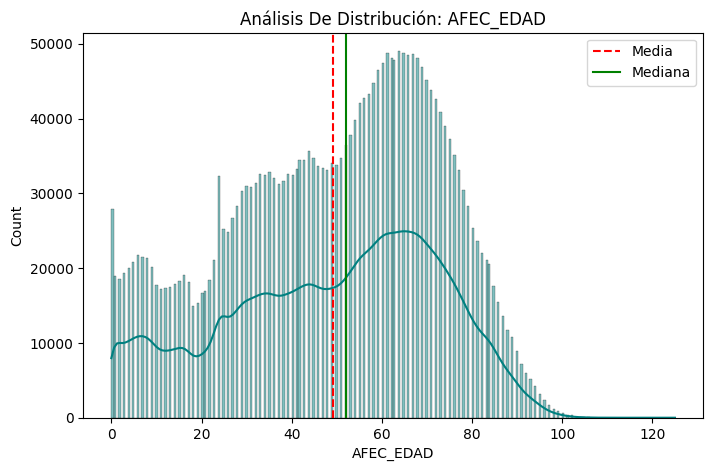

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(age_data[age], kde=True, color='teal')
plt.axvline(age_data[age].mean(), color='red', linestyle='--', label='Media')
plt.axvline(age_data[age].median(), color='green', linestyle='-', label='Mediana')
plt.title(f"Análisis De Distribución: {age}")
plt.legend()
plt.show()

In [29]:
#kurtosis
kurt_value = age_data[age].kurt()

if kurt_value > 1:
    kurt_type = "Leptocúrtica (Puntiaguda / Muchos Outliers)"
elif kurt_value < -1:
    kurt_type = "Platicúrtica (Aplanada / Pocos Outliers)"
else:
    kurt_type = "Mesocúrtica (Similar A La Normal)"

print(f"Coeficiente De Kurtosis: {kurt_value:.4f}")
print(f"Tipo De Distribución: {kurt_type}")

Coeficiente De Kurtosis: -0.8036
Tipo De Distribución: Mesocúrtica (Similar A La Normal)


<function matplotlib.pyplot.show(close=None, block=None)>

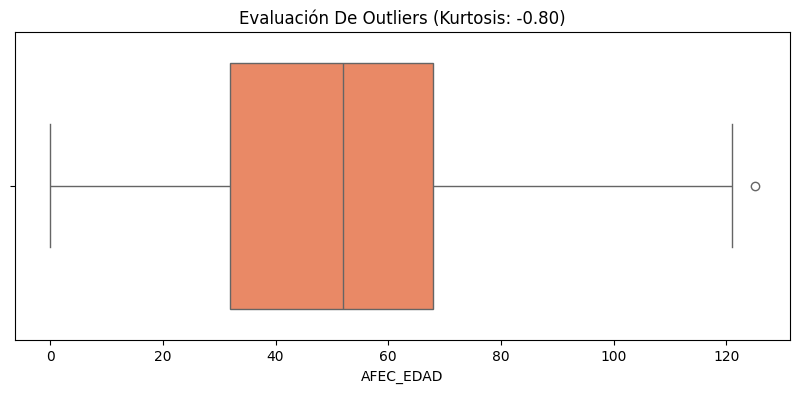

In [30]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=age_data[age], color='coral')
plt.title(f"Evaluación De Outliers (Kurtosis: {kurt_value:.2f})")
plt.show

In [33]:
#entropy
def get_entropy_report(supersalud):

    cat_var = [
    'PQRCANAL',
    'AFEC_PARENTESCO',
    'AFEC_GENERO',
    'AFEC_EDADR',
    'AFEC_EDUC',
    'AFEC_REGAFILIACION',
    'AFEC_GETNICO',
    'AFEC_POBESPECIAL',
    'ENT_NOMBRE',
    'ENT_TIPOVIG_SNS',
    'MACROMOTIVO',
    'PATOLOGIA_1',
    'CLASIFICACION_DE_RIESGO'
    ]
    
    entropy_results = []
    
    for col in cat_var:
        probs = supersalud[col].value_counts(normalize=True, dropna=True)

        h = entropy(probs, base=2)

        h_max = np.log2(len(probs)) if len(probs) > 1 else 1

        h_norm = h / h_max

        entropy_results.append({
            'Variable': col,
            'Entropy (Bits)': round(h, 4),
            'Normalized Entropy': round(h_norm, 4),
            'Unique Categories': len(probs)
        })
    
    return pd.DataFrame(entropy_results).sort_values(by='Entropy (Bits)', ascending=False)


In [35]:
supersalud_report = get_entropy_report(supersalud)
report_visual = supersalud_report.style.background_gradient(cmap='Blues', subset=['Normalized Entropy']) \
    .format({'Entropy (Bits)': '{:.4f}', 'Normalized Entropy': '{:.4f}'}) \
    .set_caption("Reporte De Entropia Por Variable")

In [36]:
report_visual

,Variable,Entropy (Bits),Normalized Entropy,Unique Categories
8,ENT_NOMBRE,4.4614,0.6240,142
3,AFEC_EDADR,2.7846,0.8383,10
11,PATOLOGIA_1,2.6556,0.5792,24
4,AFEC_EDUC,2.3914,0.7544,9
1,AFEC_PARENTESCO,2.3420,0.5730,17
0,PQRCANAL,2.0460,0.6454,9
10,MACROMOTIVO,1.9677,0.5923,10
5,AFEC_REGAFILIACION,1.2953,0.4614,7
9,ENT_TIPOVIG_SNS,1.2789,0.4034,9
2,AFEC_GENERO,0.9776,0.9776,2


In [37]:
#sparsity
total_cells = supersalud.size
null_cells = supersalud.isnull().sum().sum()

sparsity_global = (null_cells / total_cells) * 100
print(f"Sparsity Global: {sparsity_global:.2f}%")

Sparsity Global: 11.08%


In [40]:
def sparsity_report(data):
    sparsity_data = []

    for col in data.columns:
        nulls = data[col].isnull().sum()
        total = len(data)

        null_sparsity = (nulls/total) * 100

        sparsity_data.append({
            'Variable': col,
            'Null Sparsity (%)': round(null_sparsity, 2),
            'Status': 'Critico' if null_sparsity > 50 else 'Aceptable'
        })
    
    return pd.DataFrame(sparsity_data).sort_values(by='Null Sparsity (%)', ascending=False)

In [42]:
sparsity_col = sparsity_report(supersalud)
print(sparsity_col)

                        Variable  Null Sparsity (%)     Status
31            COD_SUBTIPO_MOTESP              79.36    Critico
32  SUBTIPO_DE_MOTIVO_ESPECIFICO              79.36    Critico
30     TIPO_DE_MOTIVO_ESPECIFICO              63.08    Critico
29               COD_TIPO_MOTESP              63.08    Critico
9                      AFEC_EDAD              61.73    Critico
37       CLASIFICACION_DE_RIESGO              61.73    Critico
3                       PQRCANAL              11.42  Aceptable
20                 ENT_ALIAS_SNS              11.42  Aceptable
5                  PET_COD_DEPTO               0.18  Aceptable
16                 AFEC_COD_MPIO               0.18  Aceptable
15                AFEC_COD_DEPTO               0.18  Aceptable
6                   PET_COD_MPIO               0.18  Aceptable
8                    AFEC_GENERO               0.13  Aceptable
10                    AFEC_EDADR               0.03  Aceptable
13                  AFEC_GETNICO               0.03  Ac

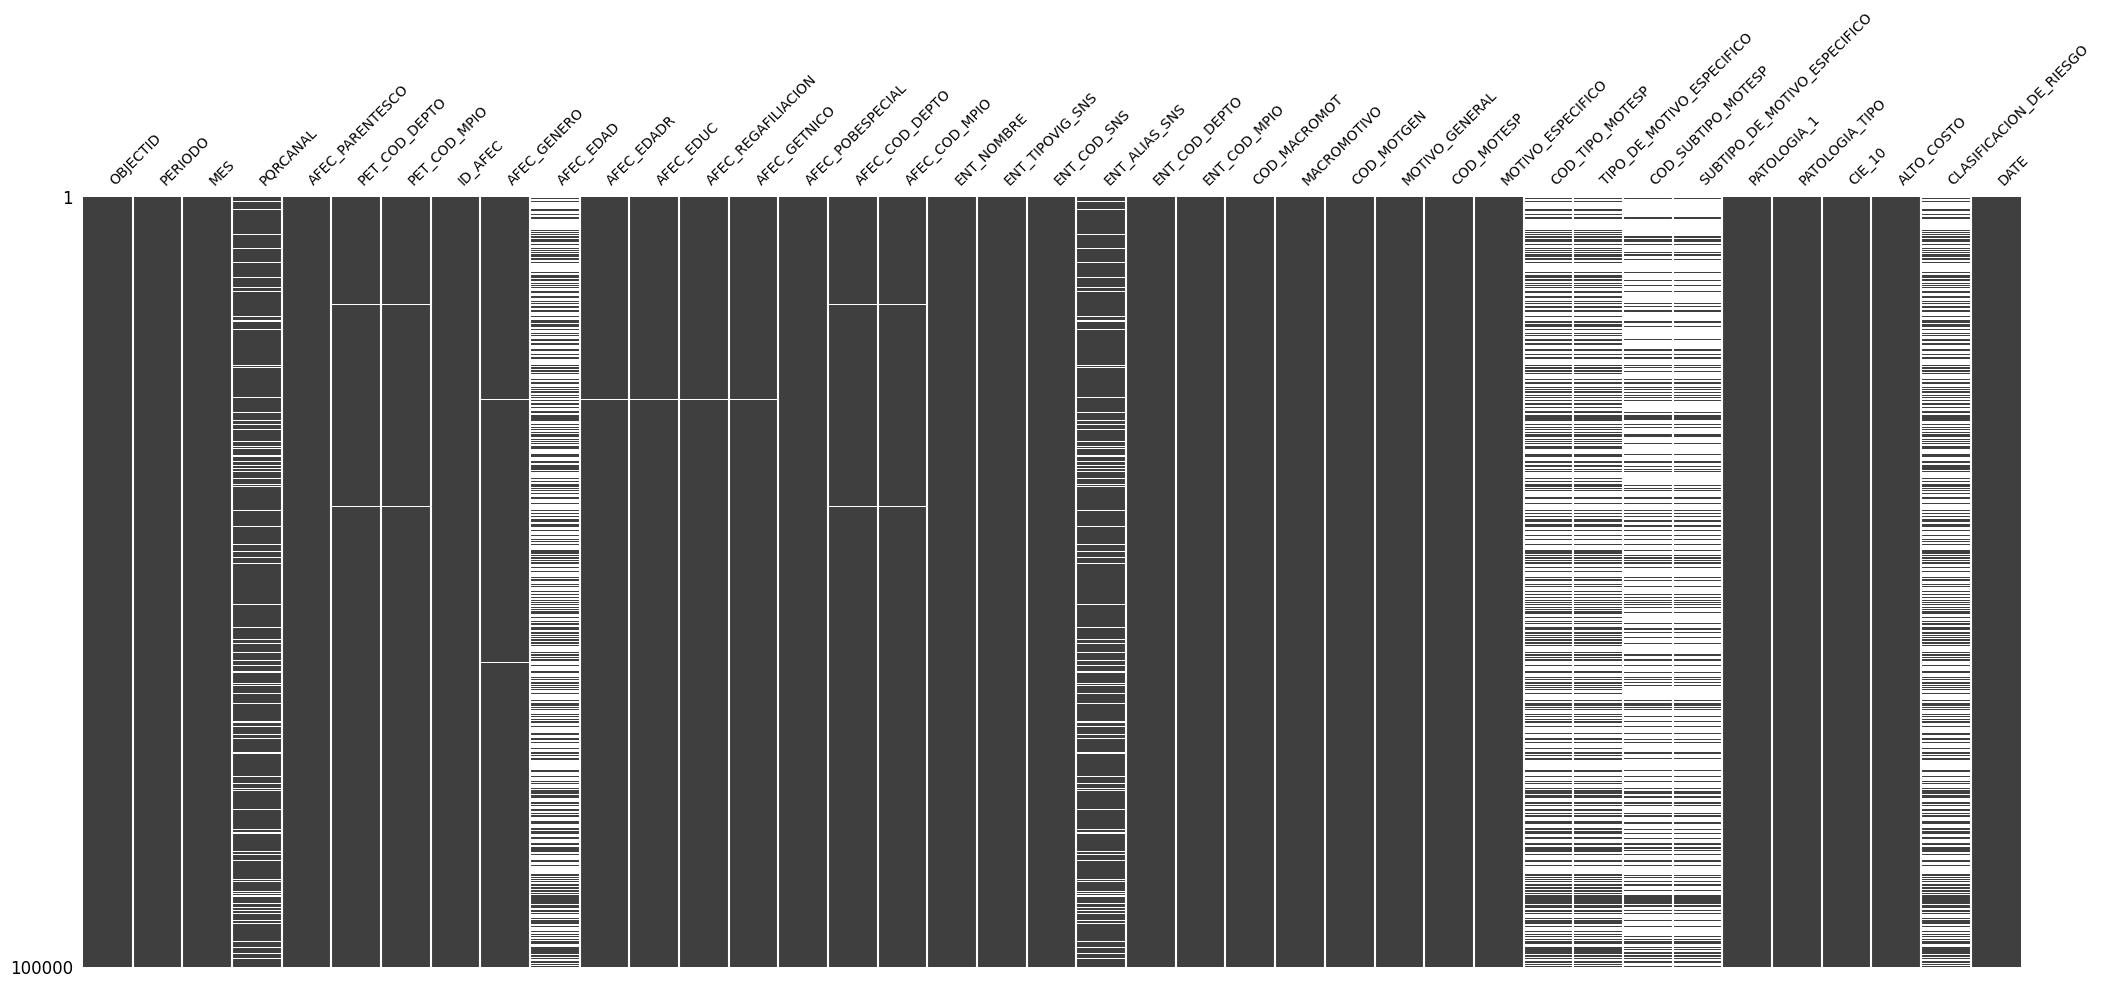

In [47]:
#nullity matrix
msno.matrix(supersalud.sample(100000),
            fontsize=10,
            labels=True,
            sparkline=False)
plt.show()

In [67]:
#gain information

all_cols = ['PQRCANAL', 'ENT_ALIAS_SNS', 'PET_COD_DEPTO', 'AFEC_COD_MPIO', 'AFEC_COD_DEPTO', 'PET_COD_MPIO', 'AFEC_GENERO', 'AFEC_EDADR', 'AFEC_GETNICO', 'AFEC_REGAFILIACION', 'AFEC_EDUC', 'AFEC_POBESPECIAL', 'AFEC_PARENTESCO', 'ENT_COD_MPIO', 'ENT_COD_DEPTO', 'ENT_COD_SNS', 'ENT_TIPOVIG_SNS', 'ENT_NOMBRE', 'COD_MACROMOT', 'MACROMOTIVO', 'COD_MOTESP', 'MOTIVO_ESPECIFICO', 'COD_MOTGEN', 'ALTO_COSTO', 'PATOLOGIA_1']
gain_data = supersalud[all_cols].copy().dropna()

In [72]:
encoders = {}
for col in all_cols:
    le = LabelEncoder()
    gain_data[col] = le.fit_transform(gain_data[col].astype(str))
    encoders[col] = le

In [74]:
n = len(all_cols)
m_matrix = pd.DataFrame(np.zeros((n, n)), columns=all_cols, index=all_cols)

In [75]:
for target_col in all_cols:
    X = gain_data.drop(columns=[target_col])
    y = gain_data[target_col]

    scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)

    cols_x = X.columns
    for i, score in enumerate(scores):
        m_matrix.loc[cols_x[i], target_col] = score

In [76]:
np.fill_diagonal(m_matrix.values, m_matrix.values.max())

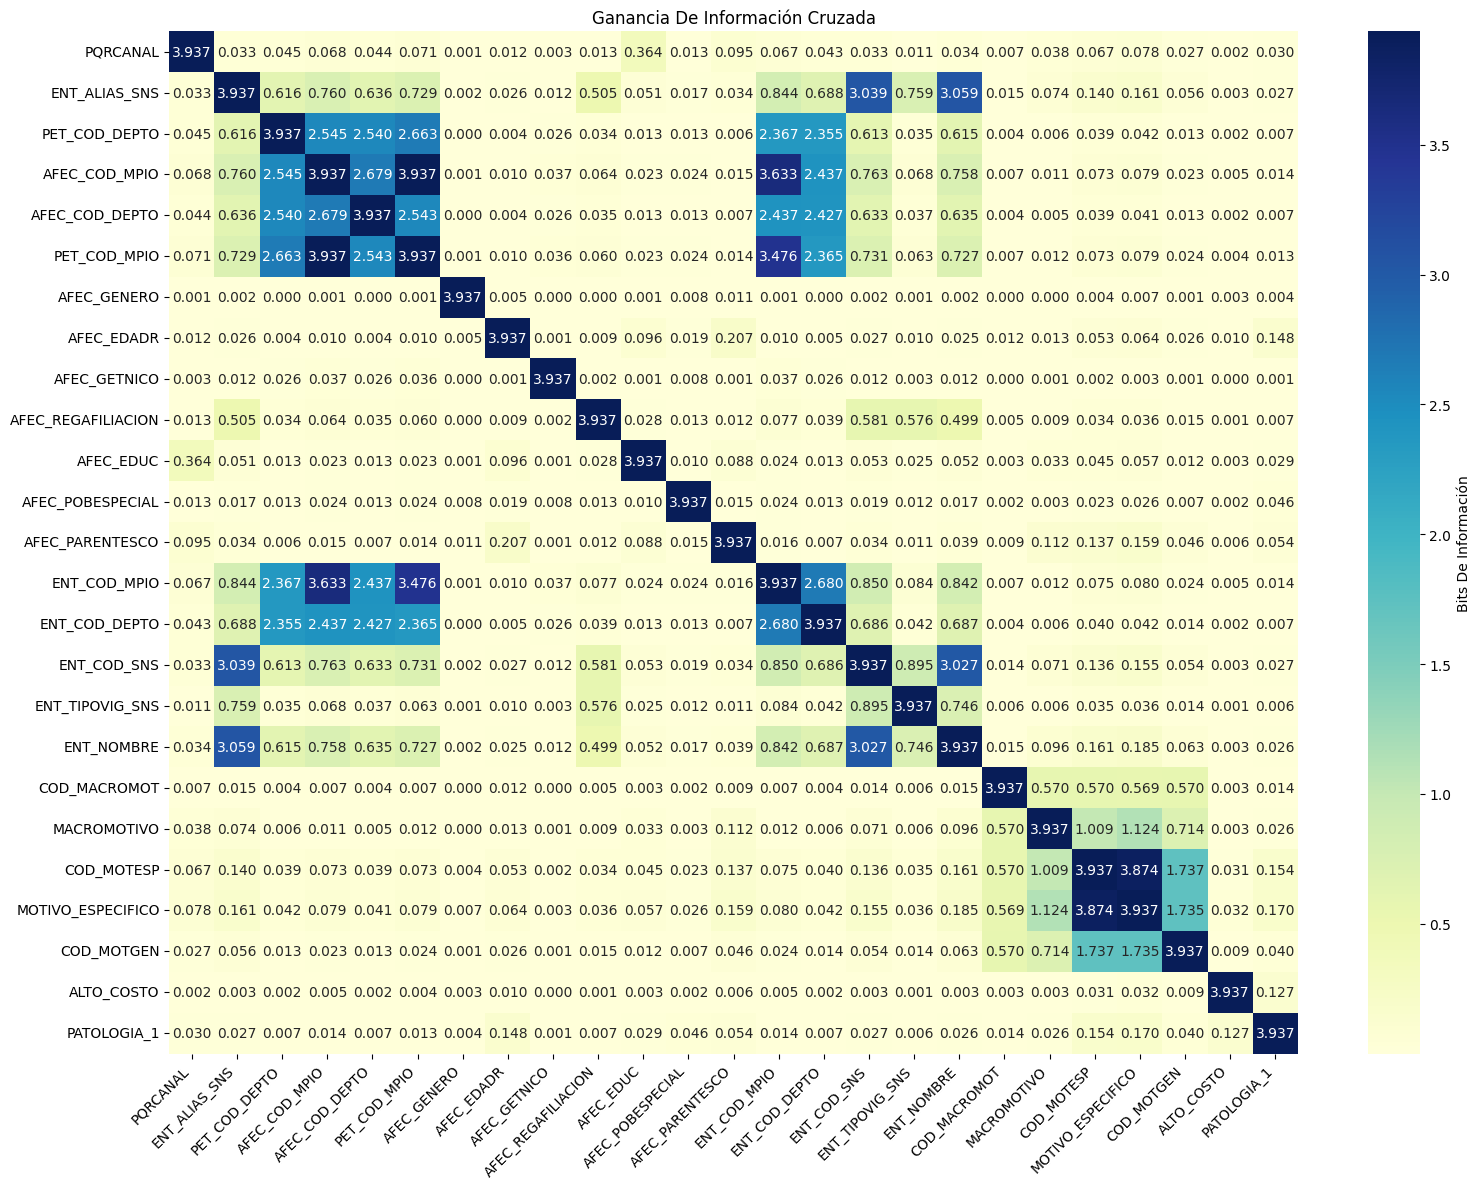

In [79]:
plt.figure(figsize=(16, 12))
sns.heatmap(m_matrix, annot=True, fmt=".3f", cmap='YlGnBu', cbar_kws={'label': 'Bits De Información'})
plt.title("Ganancia De Información Cruzada")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Charts**

In [44]:
supersalud.set_index('DATE', inplace=True)

In [81]:
monthly_trend = supersalud['OBJECTID'].resample('MS').count().reset_index()

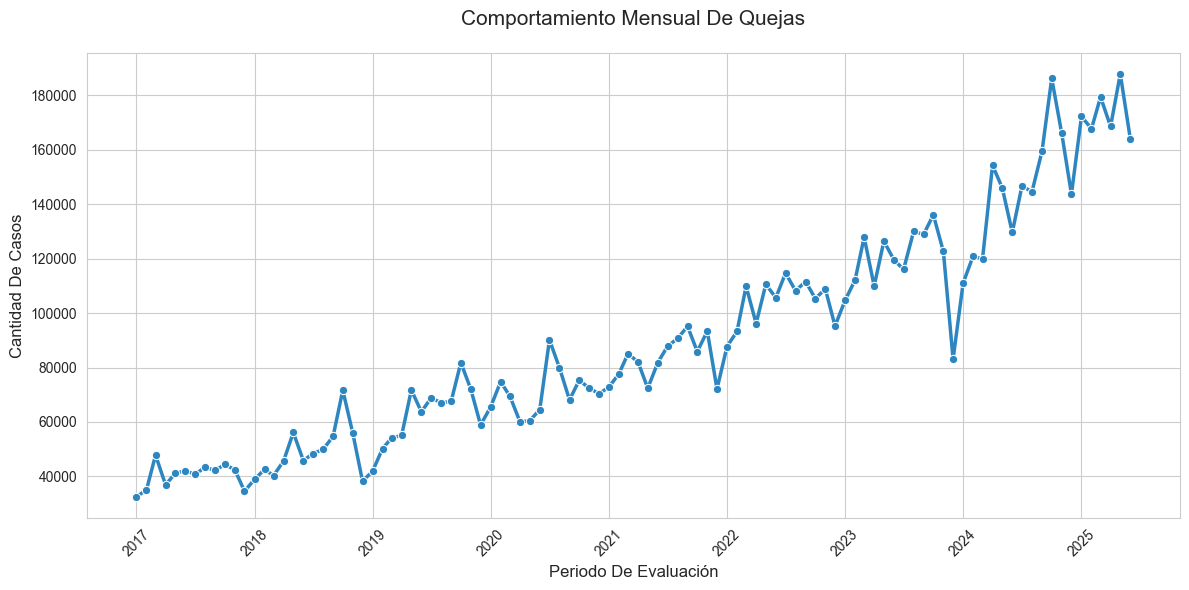

In [82]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(data=monthly_trend, x='DATE', y='OBJECTID',
             marker='o', color='#2E86C1', linewidth=2.5)

plt.title('Comportamiento Mensual De Quejas', fontsize=15, pad=20)
plt.xlabel('Periodo De Evaluación', fontsize=12)
plt.ylabel('Cantidad De Casos', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [94]:
monthly_trend['DATE'] = pd.to_datetime(monthly_trend['DATE'])

In [95]:
monthly_trend['MES'] = monthly_trend['DATE'].dt.month

In [96]:
month_group = monthly_trend.groupby('MES')['OBJECTID'].sum().reset_index()

In [97]:
dict_month = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}

In [99]:
month_group['MES_NAME'] = month_group['MES'].map(dict_month)

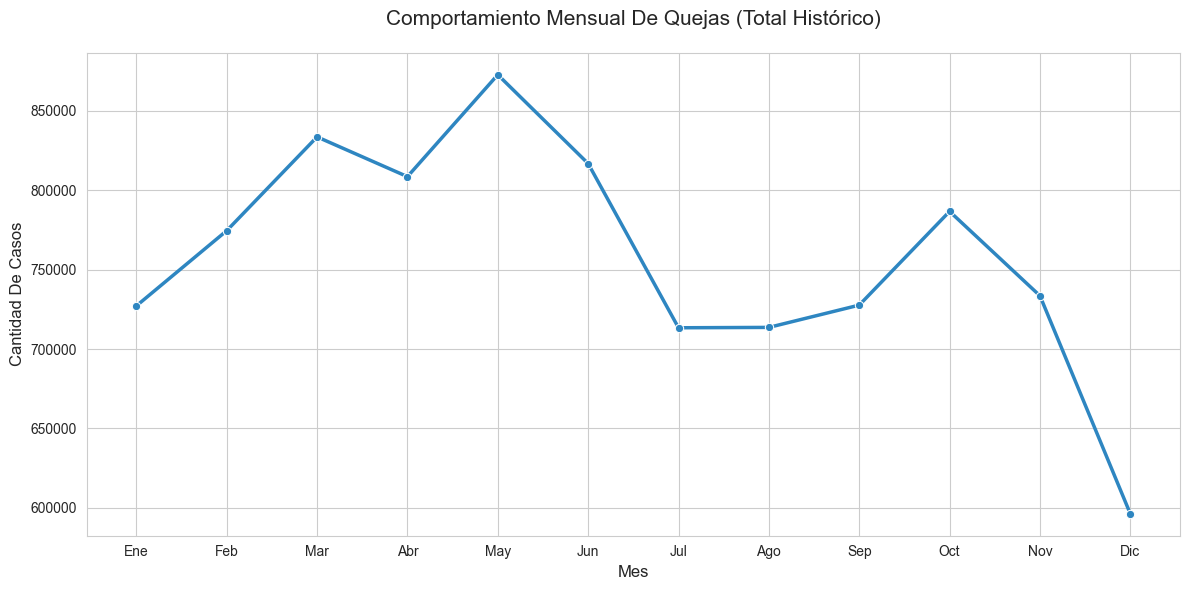

In [100]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.lineplot(data=month_group, x='MES', y='OBJECTID',
             marker='o', color='#2E86C1', linewidth=2.5)

plt.xticks(ticks=range(1, 13), labels=[dict_month[i] for i in range(1, 13)])

plt.title('Comportamiento Mensual De Quejas (Total Histórico)', fontsize=15, pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad De Casos', fontsize=12)
plt.tight_layout()

plt.show()

In [101]:
monthly_trend['DATE'] = pd.to_datetime(monthly_trend['DATE'])
monthly_trend['MES'] = monthly_trend['DATE'].dt.month
monthly_trend['YEAR'] = monthly_trend['DATE'].dt.year

In [102]:
data_grid = monthly_trend.groupby(['YEAR', 'MES'])['OBJECTID'].sum().reset_index()

In [103]:
dic_month = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

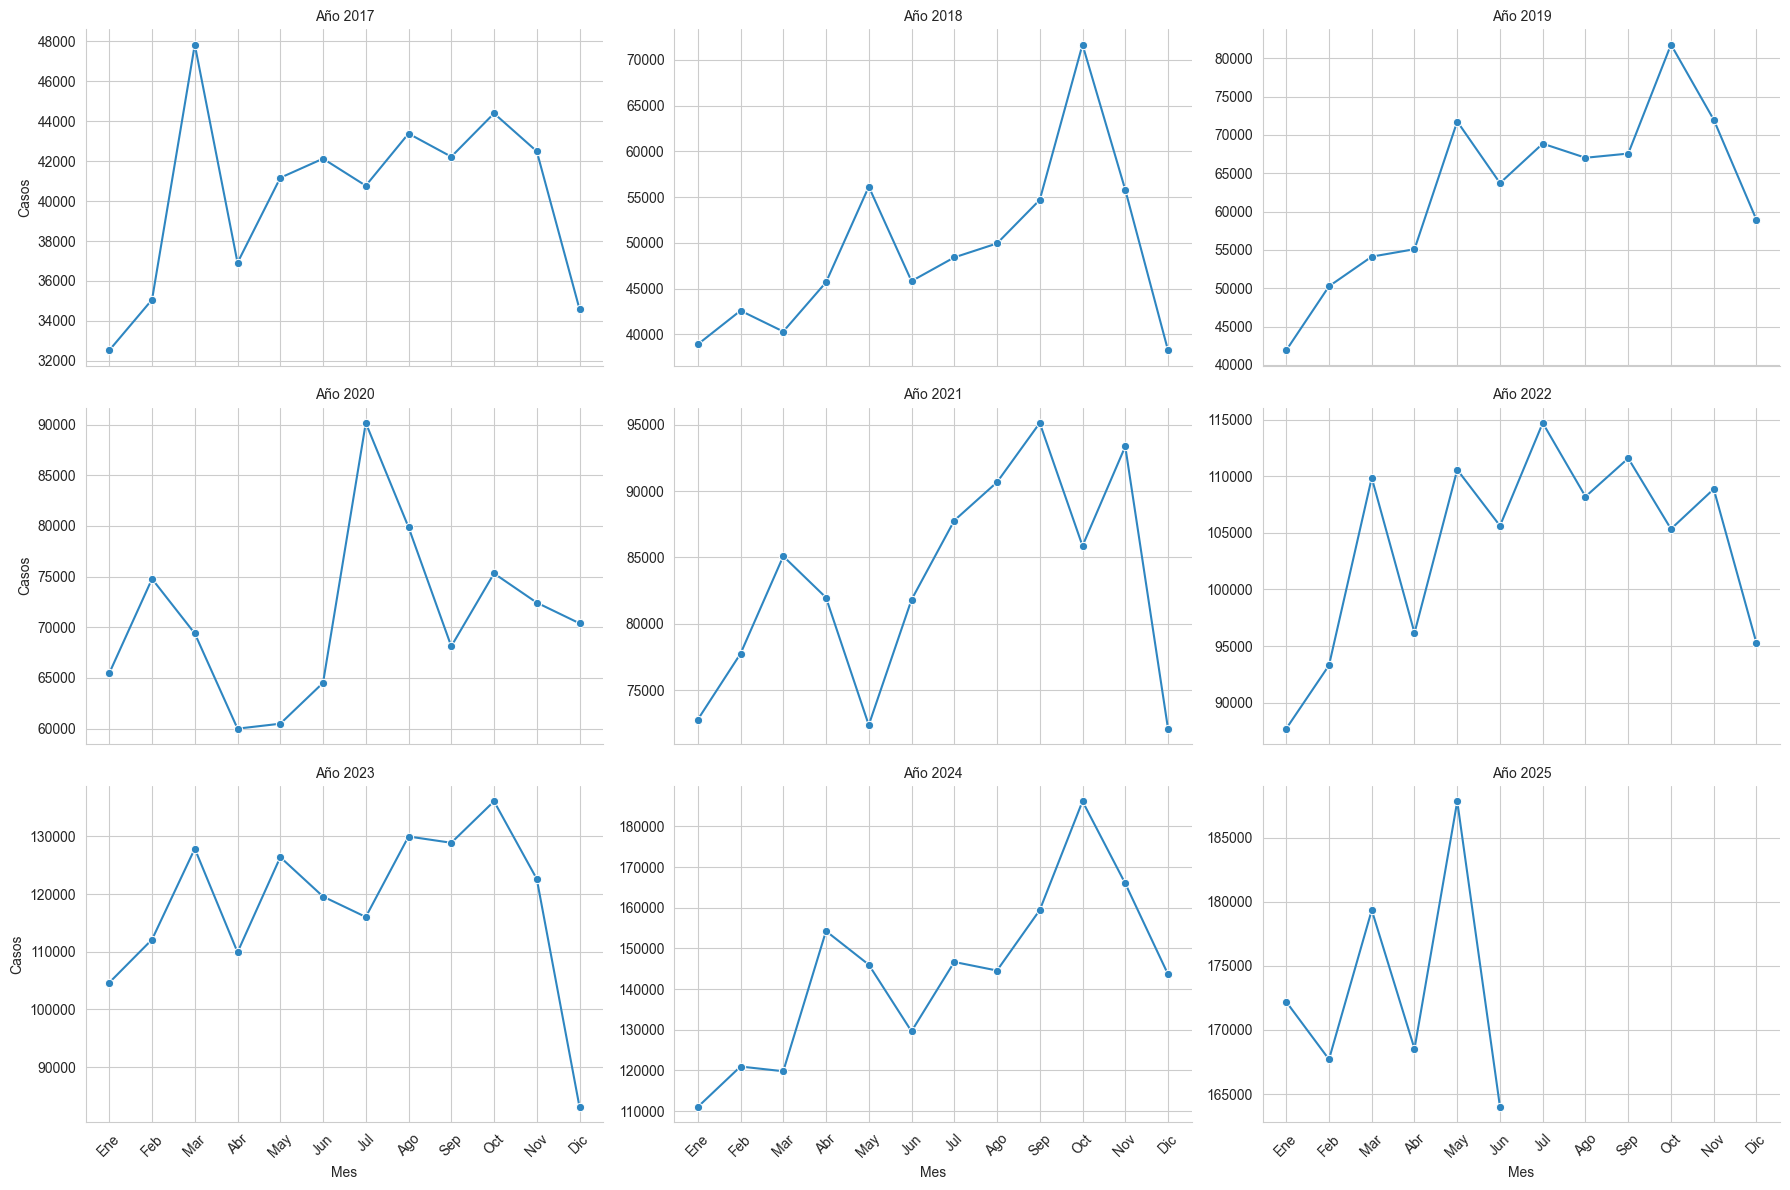

In [105]:
g = sns.FacetGrid(data_grid, col="YEAR", col_wrap=3, height=4, aspect=1.5, sharey=False)

g.map(sns.lineplot, 'MES', 'OBJECTID', marker='o', color='#2E86C1')

g.set_axis_labels('Mes', 'Casos')
g.set_titles(col_template="Año {col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([dic_month[i] for i in range(1, 13)], rotation=45)

plt.tight_layout()
plt.show()

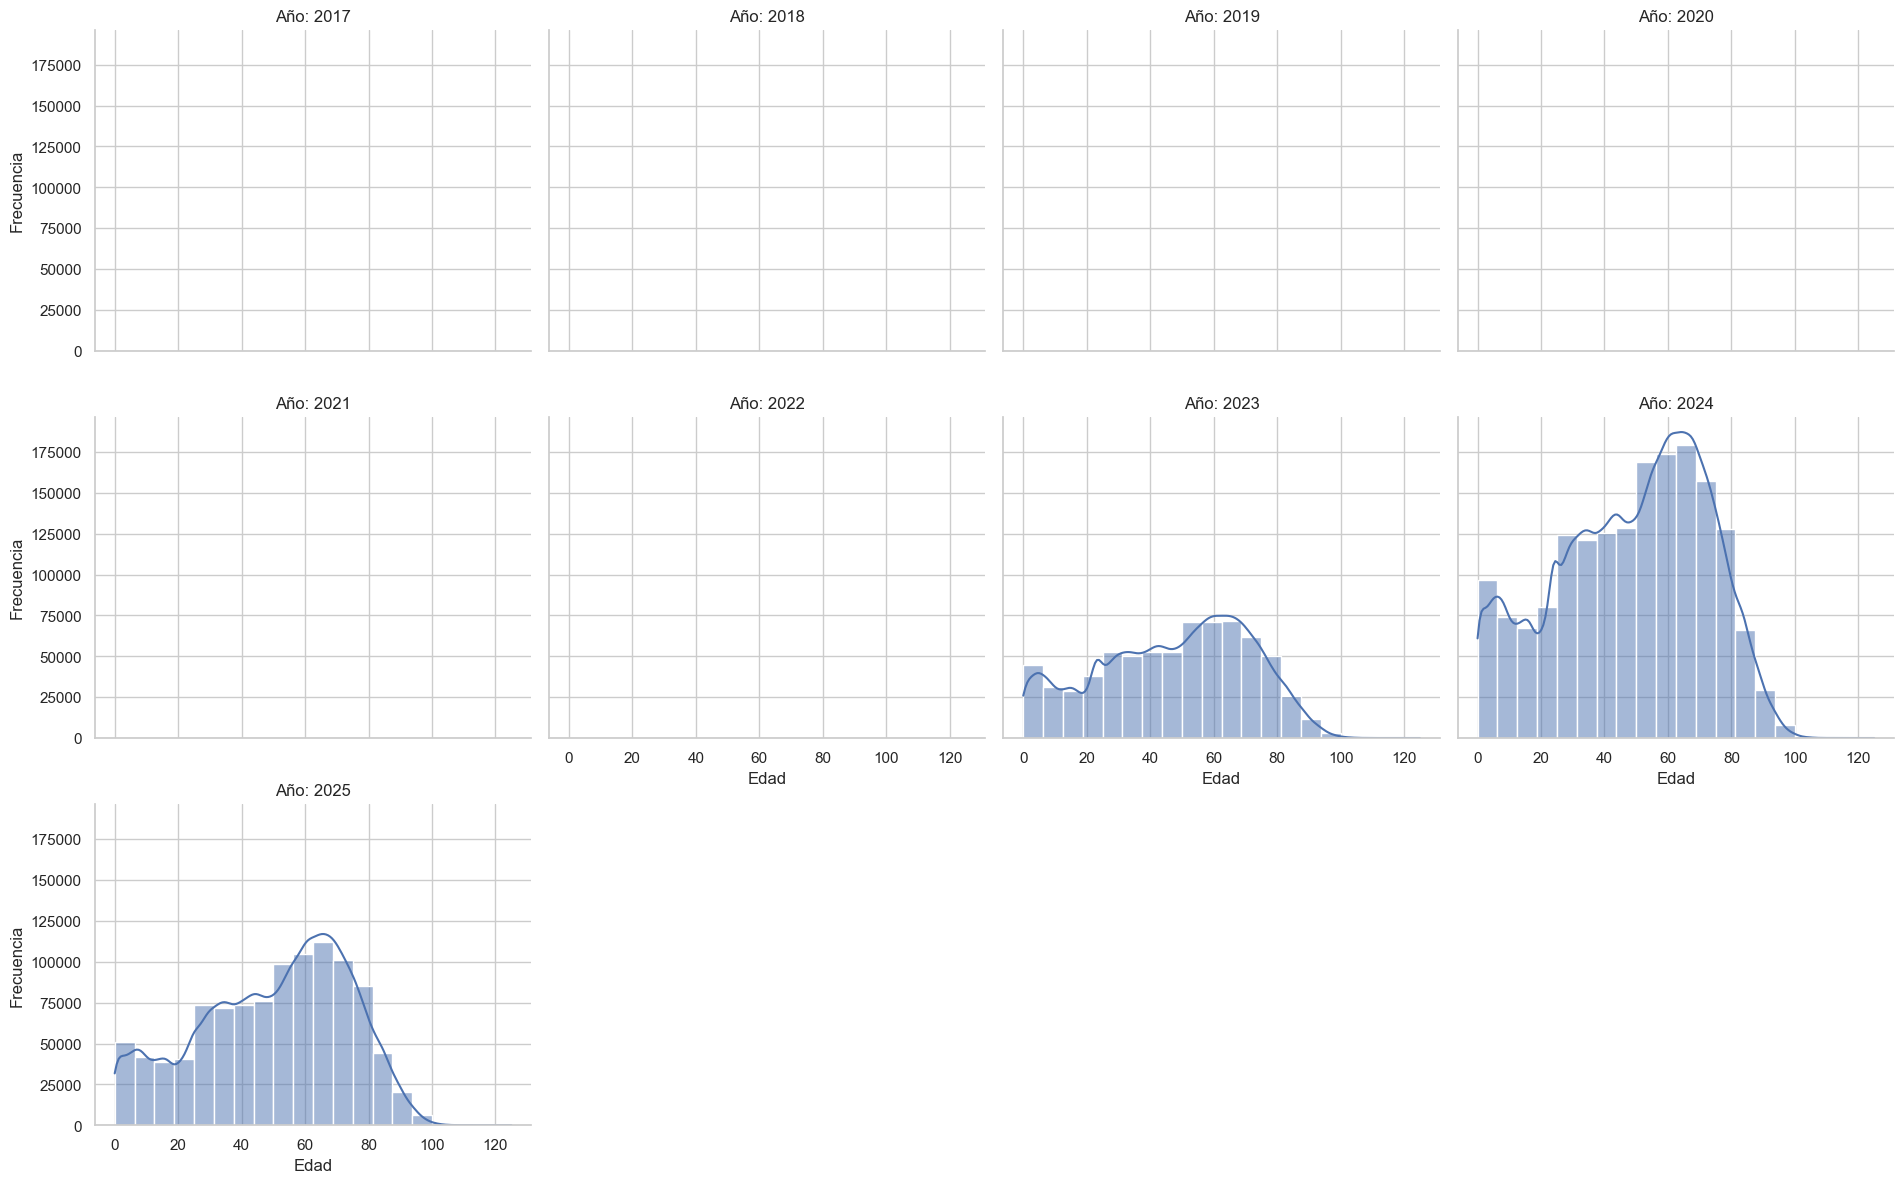

In [38]:
sns.set_theme(style="whitegrid")

h = sns.displot(
    data=dataf,
    x='AFEC_EDAD',
    col='PERIODO',
    kind="hist",
    kde=True,
    bins=20,
    col_wrap=4,
    height=4,
    aspect=1.2
)

h.set_axis_labels("Edad", "Frecuencia")
h.set_titles("Año: {col_name}")

plt.show()

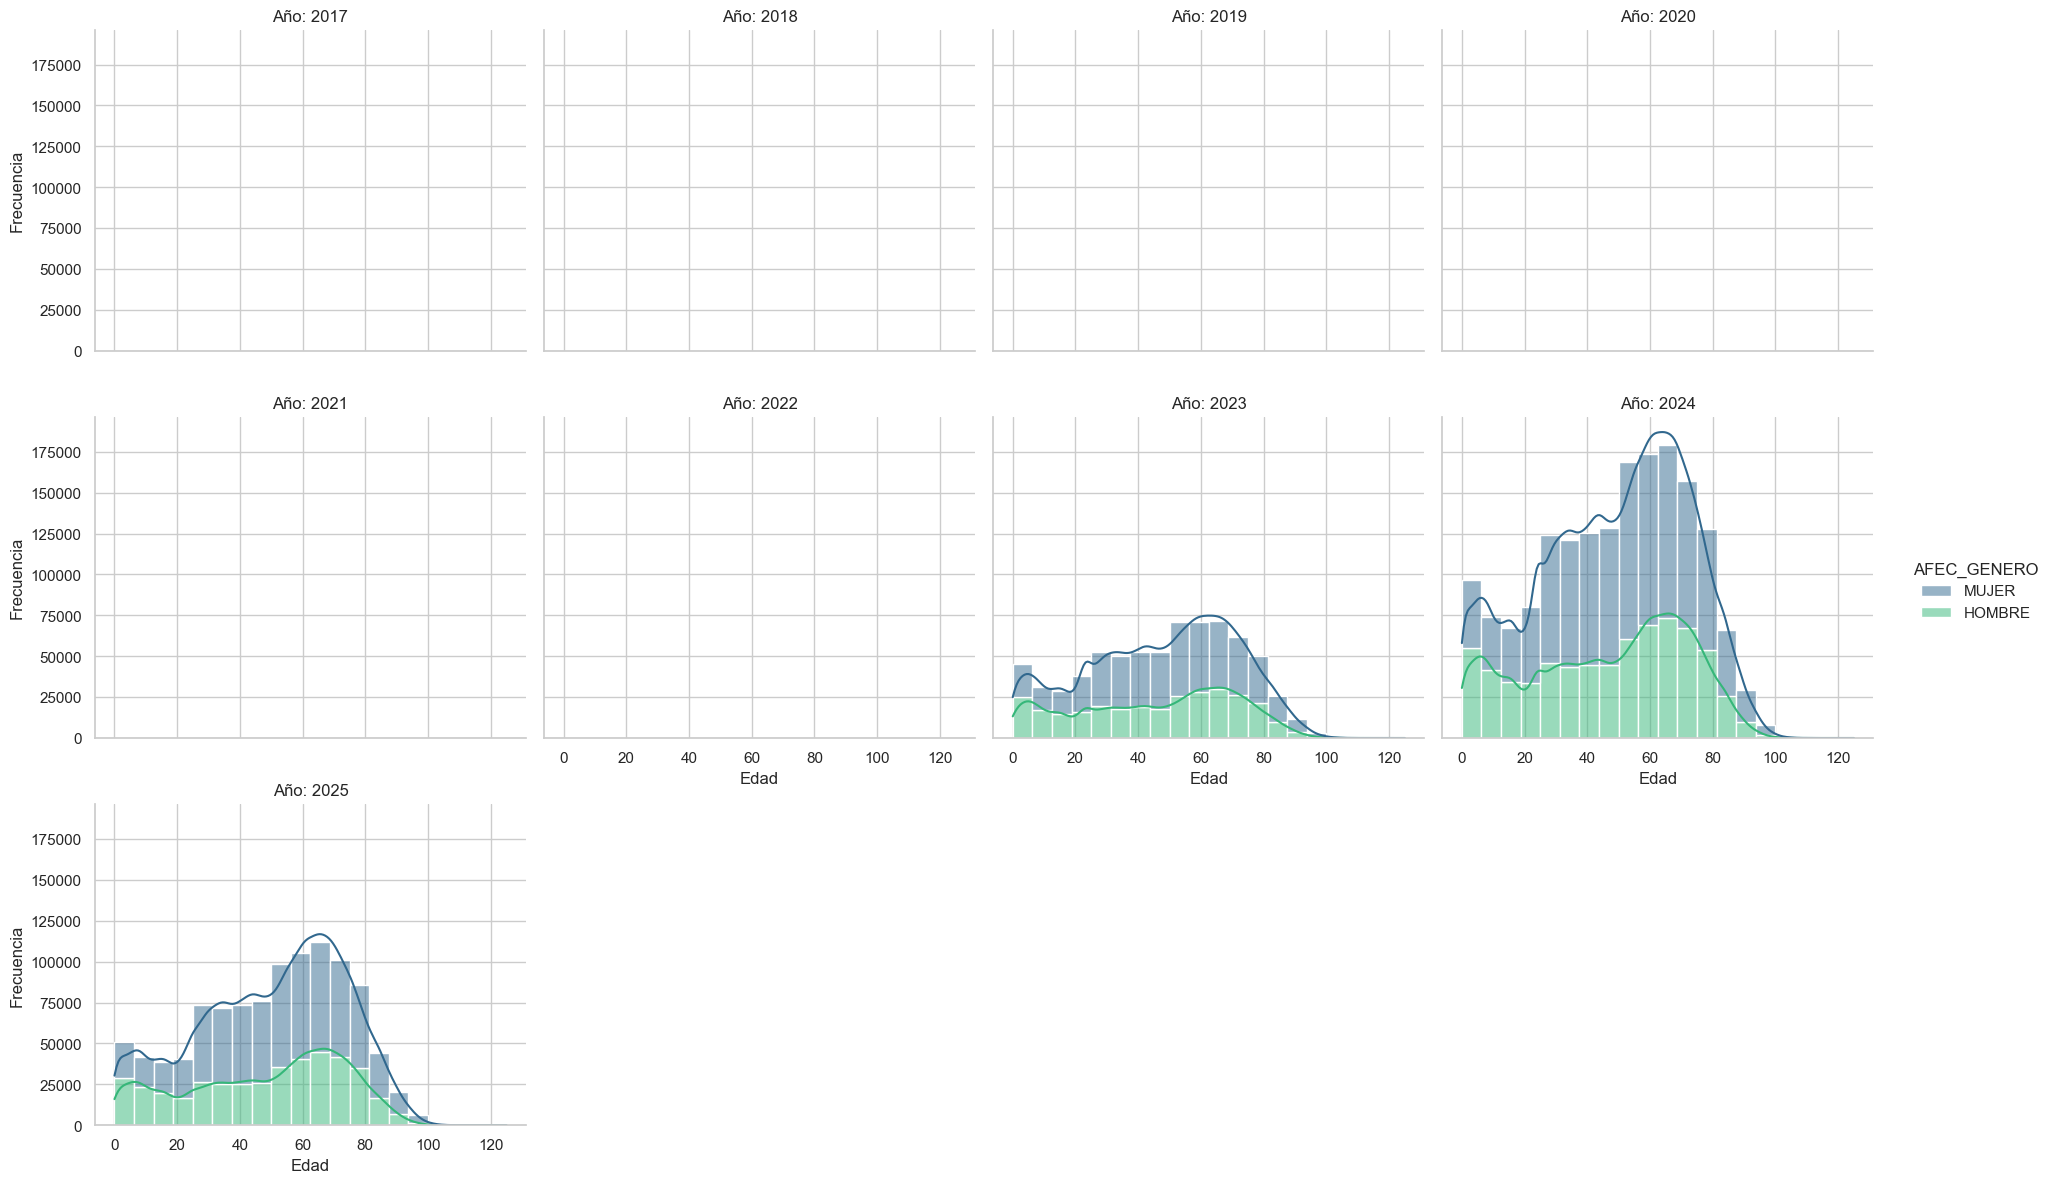

In [40]:
sns.set_theme(style="whitegrid")

h = sns.displot(
    data=dataf,
    x='AFEC_EDAD',
    col='PERIODO',
    hue='AFEC_GENERO',
    kind="hist",
    multiple="stack",
    palette="viridis",
    kde=True,
    bins=20,
    col_wrap=4,
    height=4,
    aspect=1.2
)

h.set_axis_labels("Edad", "Frecuencia")
h.set_titles("Año: {col_name}")

plt.show()

In [106]:
monthly_trend = (
    supersalud
    .groupby(['PQRCANAL'])['OBJECTID']
    .resample('MS')
    .count()
    .reset_index()
)

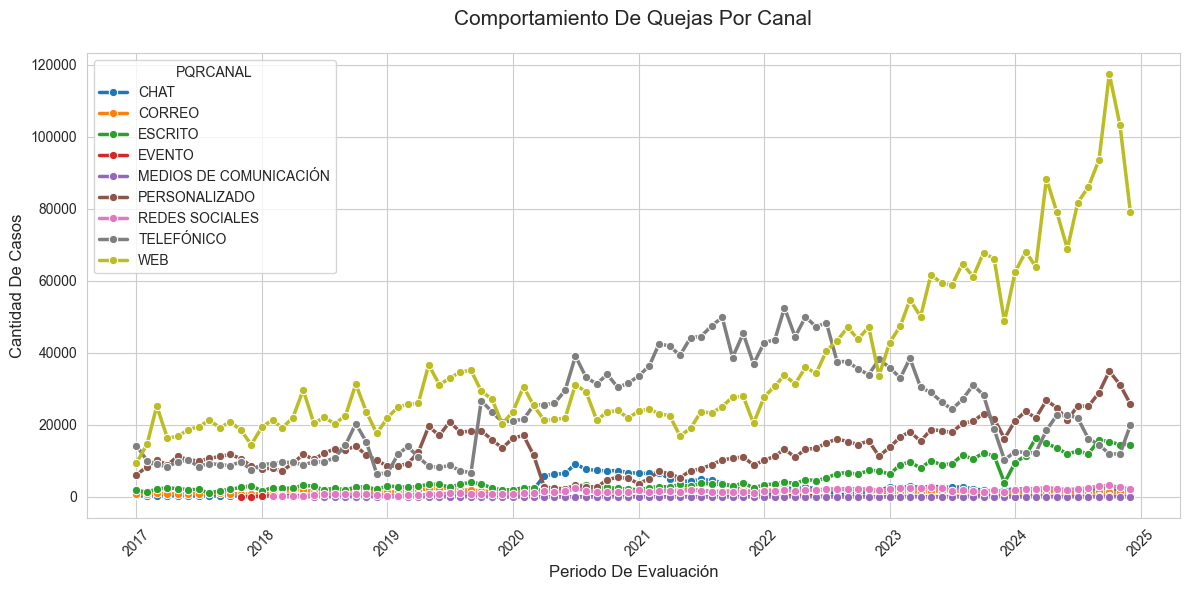

In [109]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=monthly_trend,
    x='DATE',
    y='OBJECTID',
    hue='PQRCANAL',
    marker='o',
    linewidth=2.5
)

plt.title('Comportamiento De Quejas Por Canal', fontsize=15, pad=20)
plt.xlabel('Periodo De Evaluación', fontsize=12)
plt.ylabel('Cantidad De Casos', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
monthly_trend = (
    supersalud
    .groupby(['PATOLOGIA_1'])['OBJECTID']
    .resample('MS')
    .count()
    .reset_index()
)

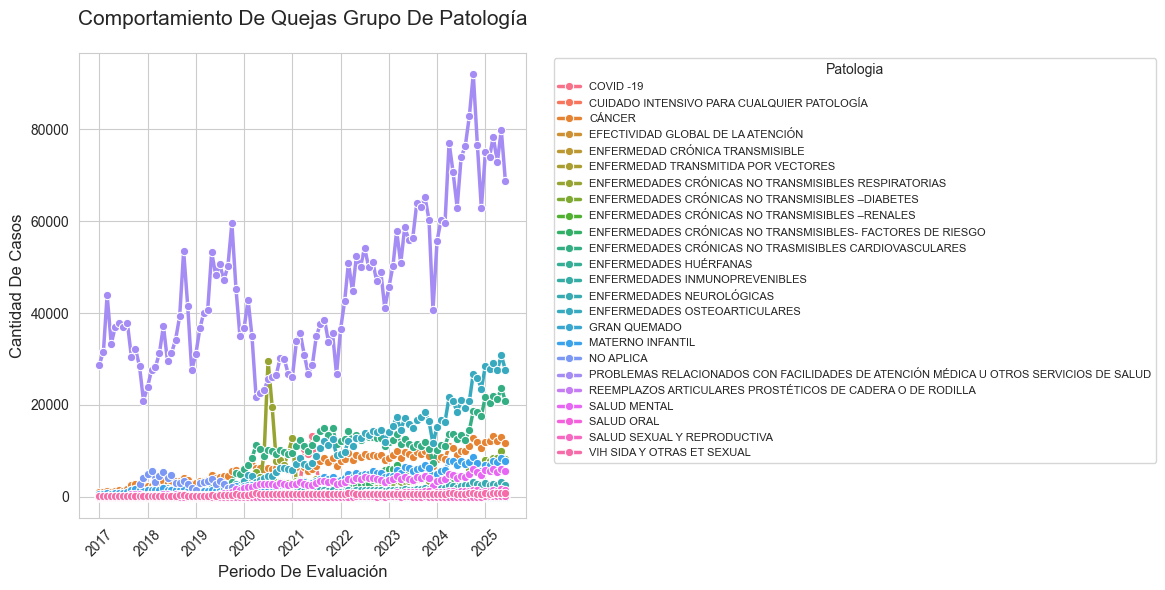

In [46]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=monthly_trend,
    x='DATE',
    y='OBJECTID',
    hue='PATOLOGIA_1',
    marker='o',
    linewidth=2.5
)

plt.title('Comportamiento De Quejas Grupo De Patología', fontsize=15, pad=20)
plt.xlabel('Periodo De Evaluación', fontsize=12)
plt.ylabel('Cantidad De Casos', fontsize=12)

plt.legend(title='Patologia', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [5]:
monthly_trend = (
    supersalud
    .groupby(['AFEC_PARENTESCO'])['OBJECTID']
    .resample('MS')
    .count()
    .reset_index()
)

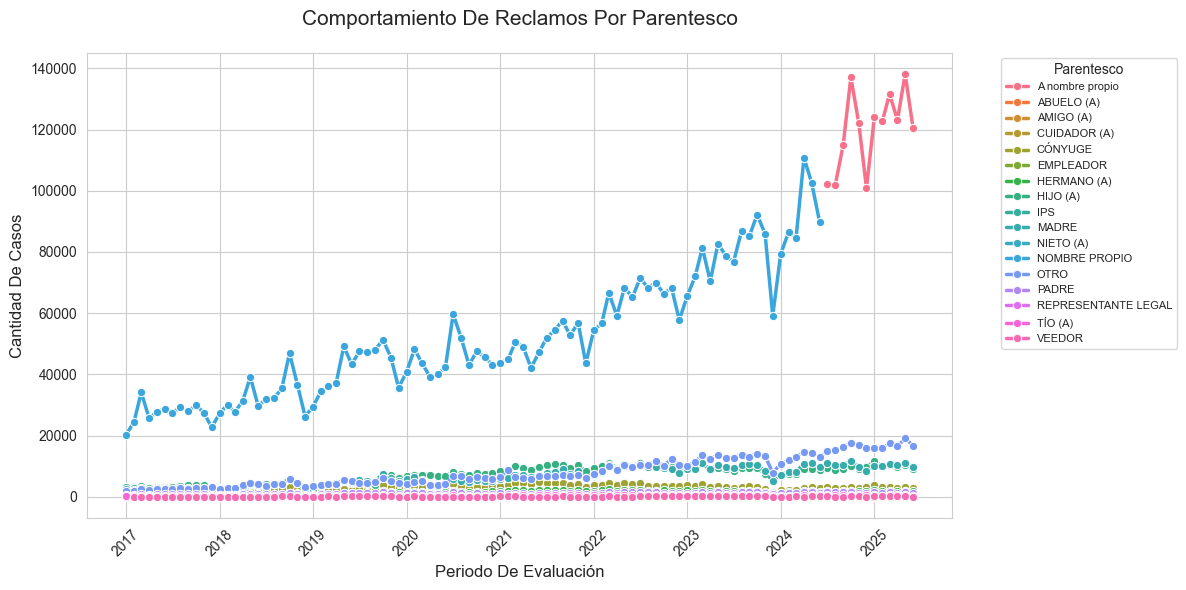

In [6]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=monthly_trend,
    x='DATE',
    y='OBJECTID',
    hue='AFEC_PARENTESCO',
    marker='o',
    linewidth=2.5
)

plt.title('Comportamiento De Reclamos Por Parentesco', fontsize=15, pad=20)
plt.xlabel('Periodo De Evaluación', fontsize=12)
plt.ylabel('Cantidad De Casos', fontsize=12)

plt.legend(title='Parentesco', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
print(supersalud.columns)

Index(['OBJECTID', 'PERIODO', 'MES', 'PQRCANAL', 'AFEC_PARENTESCO',
       'PET_COD_DEPTO', 'PET_COD_MPIO', 'ID_AFEC', 'AFEC_GENERO', 'AFEC_EDAD',
       'AFEC_EDADR', 'AFEC_EDUC', 'AFEC_REGAFILIACION', 'AFEC_GETNICO',
       'AFEC_POBESPECIAL', 'AFEC_COD_DEPTO', 'AFEC_COD_MPIO', 'ENT_NOMBRE',
       'ENT_TIPOVIG_SNS', 'ENT_COD_SNS', 'ENT_ALIAS_SNS', 'ENT_COD_DEPTO',
       'ENT_COD_MPIO', 'COD_MACROMOT', 'MACROMOTIVO', 'COD_MOTGEN',
       'MOTIVO_GENERAL', 'COD_MOTESP', 'MOTIVO_ESPECIFICO', 'COD_TIPO_MOTESP',
       'TIPO_DE_MOTIVO_ESPECIFICO', 'COD_SUBTIPO_MOTESP',
       'SUBTIPO_DE_MOTIVO_ESPECIFICO', 'PATOLOGIA_1', 'PATOLOGIA_TIPO',
       'CIE_10', 'ALTO_COSTO', 'CLASIFICACION_DE_RIESGO', 'DATE'],
      dtype='object')


In [13]:
trend_by_age = (
    supersalud
    .groupby(['AFEC_EDADR', 'AFEC_PARENTESCO', pd.Grouper(key='DATE', freq='MS')])['OBJECTID']
    .count()
    .reset_index()
)

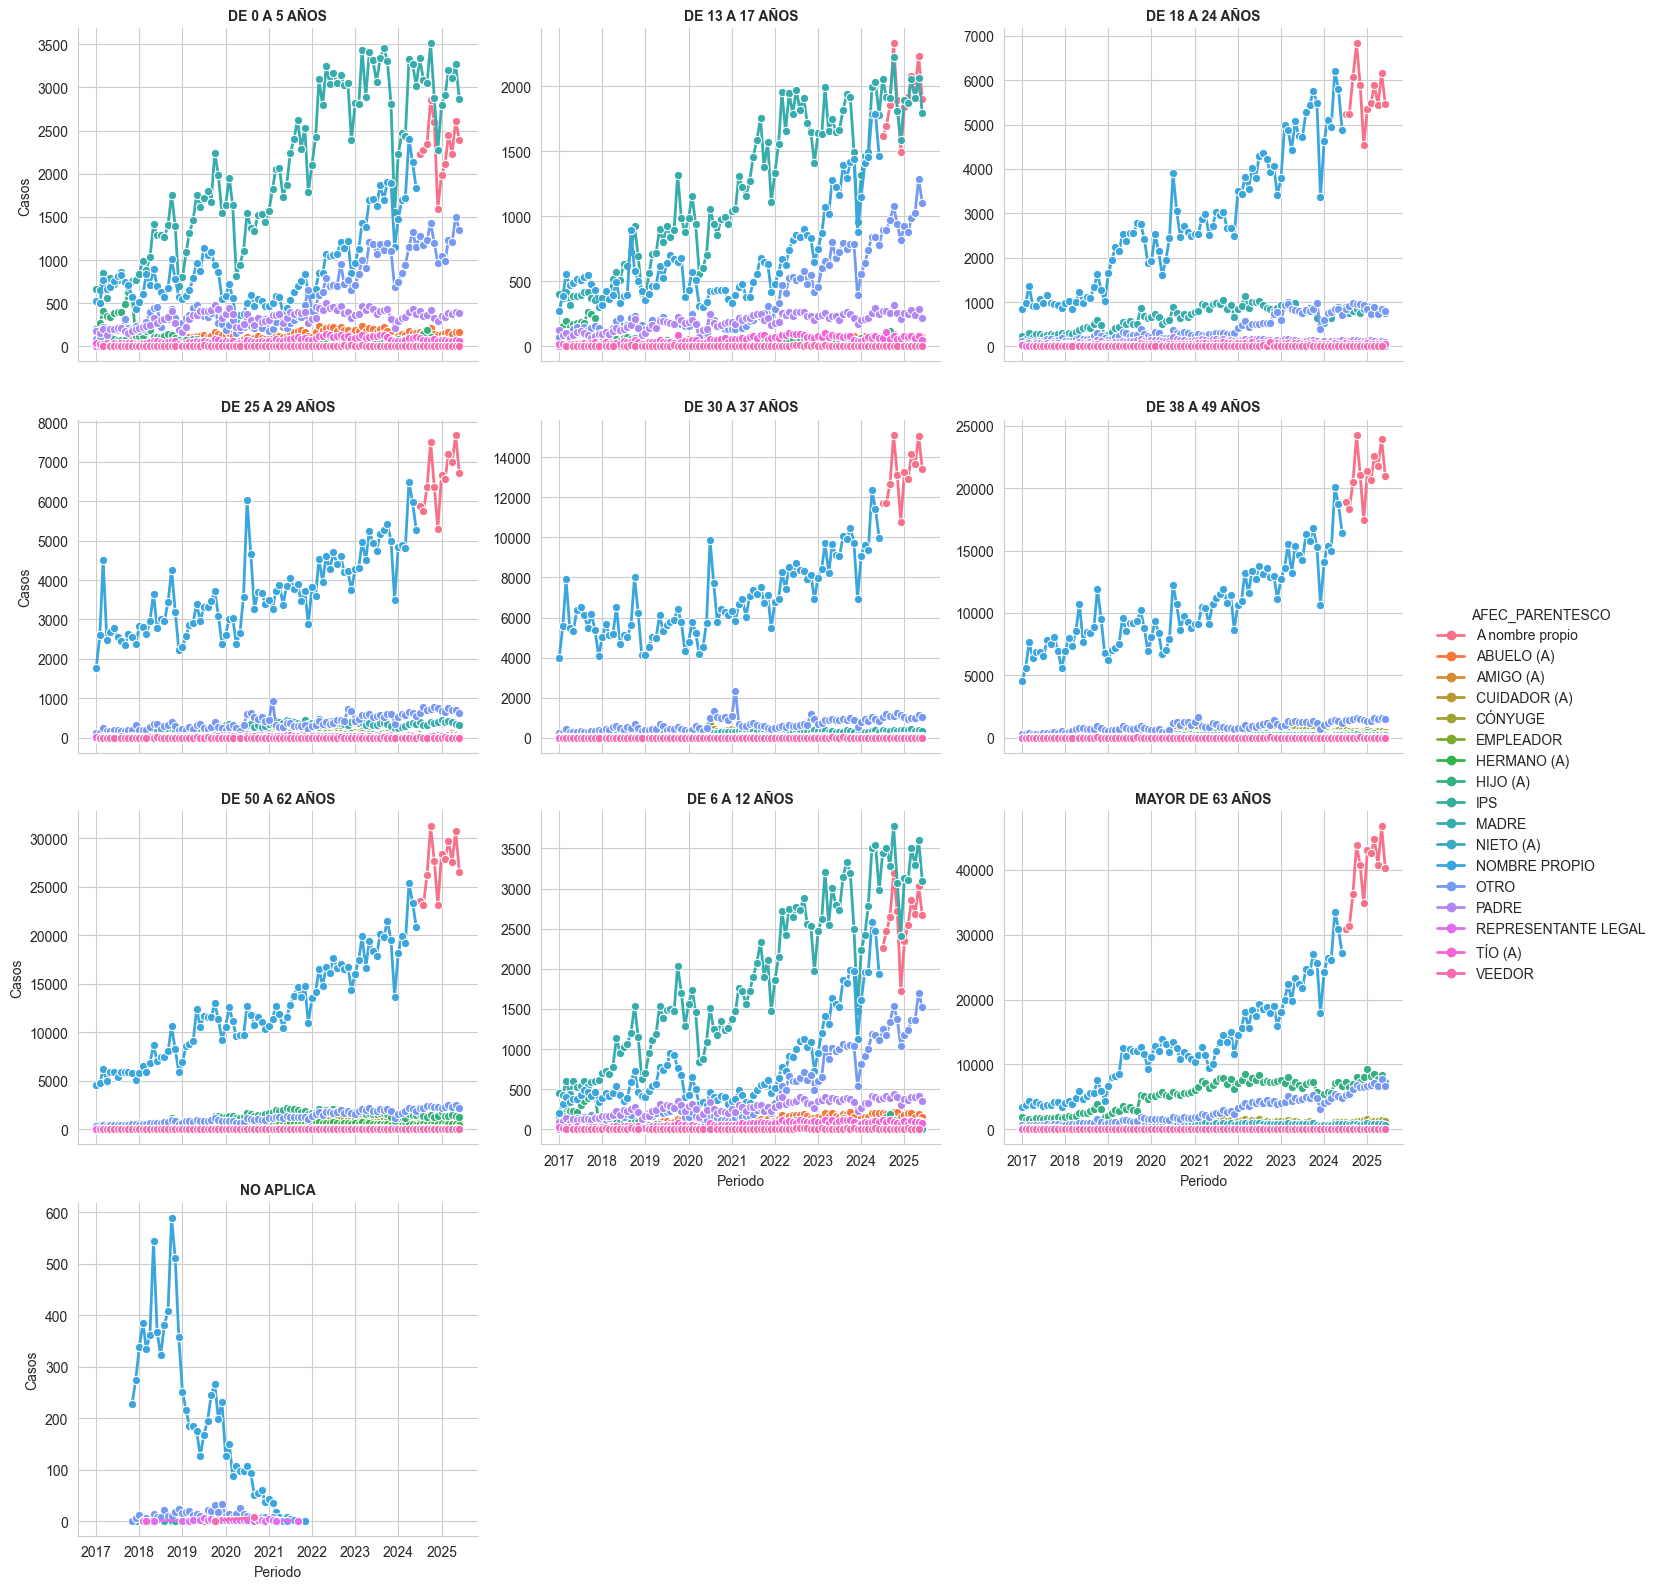

In [14]:
g = sns.relplot(
    data=trend_by_age,
    x='DATE',
    y='OBJECTID',
    hue='AFEC_PARENTESCO',
    col='AFEC_EDADR',
    kind='line',
    marker='o',
    linewidth=2,
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False}
)

g.set_titles('{col_name}', weight='bold')
g.set_axis_labels('Periodo', 'Casos')
g.tight_layout()

plt.show()

In [16]:
trend_by_age['DATE'] = pd.to_datetime(trend_by_age['DATE'])
trend_by_age['YEAR'] = trend_by_age['DATE'].dt.year

In [20]:
group_age = sorted(trend_by_age['AFEC_EDADR'].unique())

In [21]:
for group in group_age:
    print(f"\n{'='*20} Dinámica Histórica: {group} {'='*20}")

    df_group = trend_by_age[trend_by_age['AFEC_EDADR'] == group]

    group_sumary = df_group.pivot_table(
        index='AFEC_PARENTESCO',
        columns='YEAR',
        values='OBJECTID',
        aggfunc='sum'
    ).fillna(0).astype(int)

    style_table = (group_sumary.style
                   .set_caption(f"Consolidado De Casos {group}")
                   .background_gradient(cmap='YlGnBu', axis=0)
                   .format("{:,}"))
    
    display(style_table)


==================== Dinámica Histórica: DE 0 A 5 AÑOS ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
AFEC_PARENTESCO,,,,,,,,,
A nombre propio,0,0,0,0,0,0,0,"13,898","13,789"
ABUELO (A),763,"1,055","1,420","1,219","1,638","2,297","2,191","1,847",945
AMIGO (A),56,70,74,52,110,137,178,132,74
CUIDADOR (A),16,31,44,80,162,165,493,202,102
CÓNYUGE,16,80,105,151,130,17,23,28,5
EMPLEADOR,19,13,6,2,1,7,1,4,1
HERMANO (A),72,51,72,68,79,99,73,55,32
HIJO (A),"4,584","1,498",688,449,607,"1,019",994,"1,134",351
IPS,839,79,63,13,18,0,0,0,0



==================== Dinámica Histórica: DE 13 A 17 AÑOS ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
AFEC_PARENTESCO,,,,,,,,,
A nombre propio,0,0,0,0,0,0,0,"10,872","11,954"
ABUELO (A),207,317,486,466,678,801,910,897,473
AMIGO (A),61,59,88,81,144,128,167,141,63
CUIDADOR (A),18,19,32,41,82,96,278,121,105
CÓNYUGE,50,92,135,135,169,43,38,26,12
EMPLEADOR,19,2,3,5,0,2,5,2,2
HERMANO (A),235,238,294,405,562,616,524,458,213
HIJO (A),"2,110",623,388,355,499,647,626,786,308
IPS,255,31,20,8,6,0,0,0,0



==================== Dinámica Histórica: DE 18 A 24 AÑOS ====================


...

YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
AFEC_PARENTESCO,,,,,,,,,
A nombre propio,0,0,0,0,0,0,0,"15,011","16,134"
ABUELO (A),407,672,"1,034",860,"1,279","1,851","2,028","2,200","1,070"
AMIGO (A),34,62,83,59,108,119,149,170,67
CUIDADOR (A),20,32,39,62,126,141,544,192,102
CÓNYUGE,8,59,112,140,112,17,13,20,6
EMPLEADOR,6,9,7,4,2,4,2,4,2
HERMANO (A),106,123,183,180,234,241,262,199,99
HIJO (A),"3,304","1,182",581,407,594,874,999,"1,161",468
IPS,239,28,29,7,8,0,0,0,0



==================== Dinámica Histórica: MAYOR DE 63 AÑOS ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
AFEC_PARENTESCO,,,,,,,,,
A nombre propio,0,0,0,0,0,0,0,"217,792","258,260"
ABUELO (A),591,168,145,174,176,395,326,268,114
AMIGO (A),700,843,"1,431","1,542","2,663","3,118","3,180","2,926","1,625"
CUIDADOR (A),225,233,393,769,"1,154",984,"1,623",879,730
CÓNYUGE,"5,532","6,654","9,520","13,364","15,738","15,649","13,402","12,798","8,017"
EMPLEADOR,31,23,27,38,54,41,39,38,13
HERMANO (A),"1,997","2,506","3,636","5,020","6,776","6,990","6,421","6,182","3,821"
HIJO (A),"20,256","30,060","41,131","65,297","84,519","90,757","81,374","81,804","49,379"
IPS,783,175,153,25,46,0,0,0,0



==================== Dinámica Histórica: NO APLICA ====================


YEAR,2017,2018,2019,2020,2021
AFEC_PARENTESCO,,,,,
ABUELO (A),0,1,0,0,0
CUIDADOR (A),0,0,1,0,0
CÓNYUGE,1,2,0,1,0
EMPLEADOR,2,21,38,34,6
HIJO (A),0,0,0,1,0
IPS,1,4,3,0,0
MADRE,0,1,0,1,0
NOMBRE PROPIO,501,"4,895","2,439","1,069",125
OTRO,7,133,216,124,15


In [25]:
trend_disease = (
    supersalud
    .groupby(['PATOLOGIA_1', pd.Grouper(key='DATE', freq='MS')])['OBJECTID']
    .count()
    .reset_index()
)

In [30]:
trend_disease['DATE'] = pd.to_datetime(trend_by_age['DATE'])
trend_disease['YEAR'] = trend_by_age['DATE'].dt.year

In [31]:
trend_disease.columns

Index(['PATOLOGIA_1', 'DATE', 'OBJECTID', 'YEAR'], dtype='object')

In [34]:
print(f"\n{'='*20} Dinámica Según Patologia: {group} {'='*20}")

disease_sumary = trend_disease.pivot_table(
    index='PATOLOGIA_1',
    columns='YEAR',
    values='OBJECTID',
    aggfunc='sum'
).fillna(0).astype(int)

disease_sumary = disease_sumary.sort_values(by=2025, ascending=False)

style_table = (disease_sumary.style
               .set_caption(f"Consolidado De Casos Según Patología")
               .background_gradient(cmap='YlGnBu', axis=0)
               .format("{:,}"))
    
display(style_table)


==================== Dinámica Según Patologia: NO APLICA ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
PATOLOGIA_1,,,,,,,,,
PROBLEMAS RELACIONADOS CON FACILIDADES DE ATENCIÓN MÉDICA U OTROS SERVICIOS DE SALUD,"327,910","408,422","586,716","689,238","884,113","586,981","355,311","509,467","269,595"
ENFERMEDADES OSTEOARTICULARES,"195,069",338,"15,081","13,687","31,841","72,752","127,019","275,990","232,268"
CÁNCER,"88,569","107,590","129,412","65,549","35,606","47,546","74,781","80,220","48,573"
MATERNO INFANTIL,"37,604","17,979","15,934","25,969","34,899","52,779","64,459","77,061","42,926"
SALUD MENTAL,"44,747","46,975","54,902","35,058","5,031","5,195","20,709","33,165","19,395"
ENFERMEDADES NEUROLÓGICAS,"23,127","16,179","3,760","4,258","12,962","14,245","16,009","18,588","10,901"
ENFERMEDADES CRÓNICAS NO TRANSMISIBLES RESPIRATORIAS,"11,177","3,253","4,373","23,419","103,372","15,367","13,276","12,723","7,917"
ENFERMEDADES HUÉRFANAS,"12,085","10,850","14,422","16,794","18,680","16,799","8,867","9,155","7,531"
COVID -19,"2,309",293,112,36,0,0,0,"44,574","7,159"


In [35]:
trend_alto_costo = (
    supersalud
    .groupby(['ALTO_COSTO', pd.Grouper(key='DATE', freq='MS')])['OBJECTID']
    .count()
    .reset_index()
)

In [37]:
trend_alto_costo['DATE'] = pd.to_datetime(trend_alto_costo['DATE'])
trend_alto_costo['YEAR'] = trend_alto_costo['DATE'].dt.year

In [38]:
print(f"\n{'='*20} Dinámica Según Alto Costo {'='*20}")

alto_costo_sumary = trend_alto_costo.pivot_table(
    index='ALTO_COSTO',
    columns='YEAR',
    values='OBJECTID',
    aggfunc='sum'
).fillna(0).astype(int)

alto_costo_sumary = alto_costo_sumary.sort_values(by=2025, ascending=False)

style_table = (alto_costo_sumary.style
               .set_caption(f"Consolidado De Casos Según Alto Costo")
               .background_gradient(cmap='YlGnBu', axis=0)
               .format("{:,}"))
    
display(style_table)


==================== Dinámica Según Alto Costo ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
ALTO_COSTO,,,,,,,,,
No aplica,"476,518","574,831","724,530","769,579","940,863","1,181,618","1,346,273","1,650,086","990,881"
Quimioterapia y radioterapia para el cáncer,"4,119","7,639","14,240","50,082","24,096","27,206","27,606","29,854","18,854"
Reemplazos articulares,186,357,"2,035","4,033","4,699","8,633","11,914","12,444","7,273"
Diagnóstico y manejo del paciente infectado por VIH,449,994,"2,319","6,373","6,576","7,344","6,610","7,755","4,390"
Manejo quirúrgico para enfermedades del corazón,155,149,"1,213","3,302","2,468","3,469","4,234","4,682","3,723"
Manejo de pacientes en Unidades de cuidados intensivos,100,221,"1,479","3,561","5,430","3,872","4,367","4,809","2,965"
Hemodiálisis,298,622,"1,301","4,646","3,843","4,520","4,400","4,791","2,749"
TRASPLANTE RENAL,96,"1,010","1,650","3,086","2,483","2,766","2,970","3,766","2,502"
Diálisis peritoneal,60,284,611,"1,899","2,066","2,047","2,150","2,220","1,375"


In [39]:
trend_macromotivo = (
    supersalud
    .groupby(['MACROMOTIVO', pd.Grouper(key='DATE', freq='MS')])['OBJECTID']
    .count()
    .reset_index()
)

In [40]:
trend_macromotivo['DATE'] = pd.to_datetime(trend_macromotivo['DATE'])
trend_macromotivo['YEAR'] = trend_macromotivo['DATE'].dt.year

In [41]:
print(f"\n{'='*20} Dinámica Según Macromotivo {'='*20}")

macromotivo_sumary = trend_macromotivo.pivot_table(
    index='MACROMOTIVO',
    columns='YEAR',
    values='OBJECTID',
    aggfunc='sum'
).fillna(0).astype(int)

macromotivo_sumary = macromotivo_sumary.sort_values(by=2025, ascending=False)

style_table = (macromotivo_sumary.style
               .set_caption(f"Consolidado De Casos Según Macromotivo")
               .background_gradient(cmap='YlGnBu', axis=0)
               .format("{:,}"))
    
display(style_table)


==================== Dinámica Según Macromotivo ====================


YEAR,2017,2018,2019,2020,2021,2022,2023,2024,2025
MACROMOTIVO,,,,,,,,,
BARRERAS EN EL ACCESO A TECNOLOGÍAS Y SERVICIOS DE SALUD Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO,0,0,0,0,0,0,0,0,"963,264"
INSATISFACCIÓN DEL USUARIO CON EL PROCESO ADMINISTRATIVO,"55,596","56,763","59,217","58,543","62,182","82,880","85,909","125,985","59,485"
INSATISFACCIÓN RELACIONADA CON LA ATENCIÓN EN SALUD,0,0,0,0,0,0,"14,577","31,384","16,151"
INSATISFACCIÓN RELACIONADA CON INFRAESTRUCTURA Y LOGÍSTICA,0,0,0,0,0,0,"1,023","1,568",706
BARRERAS EN EL ACCESO A TECNOLOGÍAS Y SERVICIOS DE SALUD; Y OTROS ELEMENTOS COMPLEMENTARIOS PARA LA ATENCIÓN DEL USUARIO,0,0,0,0,0,0,"645,250","1,569,132",0
FALTA DE DISPONIBILIDAD O INAPROPIADO MANEJO DEL RECURSOS HUMANO Y FÍSICO PARA LA ATENCIÓN,725,"1,450","2,587","2,142","1,439","1,734",597,0,0
DEFICIENCIA EN LA EFECTIVIDAD DE LA ATENCIÓN EN SALUD,"29,260","28,261","31,433","55,448","47,726","78,268","19,361",0,0
NO RECONOCIMIENTO DE LAS PRESTACIONES ECONÓMICAS,"15,134","22,860","29,639","33,017","37,752","39,932","24,064",0,0
"PETICIONES, QUEJAS Y RECLAMOS INTERPUESTAS POR IPS-EPS, ENTIDADES TERRITORIALES Y ORGANISMOS DE CONTROL Y VIGILANCIA",235,"2,095","5,813","6,924","3,449","1,660",446,0,0
